# 02 - Data Preprocessing, Deduplication, and Dataset Segregation
**Project**: Personalized Cardiovascular Risk Assessment 

This notebook performs:
1. **Raw Data Ingestion** from UCI Cleveland Heart Disease repository.
2. **Deduplication Check** for both tabular clinical records and ECG diagnostic images.
3. **Data Cleaning & Missing Value Imputation** with parameters fit strictly on the training partition.
4. **Stratified Segregation** into **Train (70%)**, **Validation (15%)**, and **Test (15%)** sets.
5. **Feature Standardization (`StandardScaler`)** with zero data leakage.
6. **Visual Validation** of target balances, distributions, and exported splits.


In [1]:
import os
import sys
import json
from pathlib import Path

# Ensure project root is in sys.path
project_root = Path(os.path.abspath('..')) if Path('.').resolve().name == 'notebooks' else Path('.').resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
os.chdir(project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import (
    fetch_or_load_raw_data,
    deduplicate_tabular,
    deduplicate_and_manifest_images,
    clean_and_impute_missing,
    split_data_stratified,
    scale_features_no_leakage,
    run_full_preprocessing_pipeline
)

# Plot styling
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print(f"Working directory: {os.getcwd()}")
print("Imports and environment ready!")


Working directory: D:\Personalized_Cardiovascular_Risk_Assessment
Imports and environment ready!


## 1. Execute Preprocessing & Segregation Pipeline

In [2]:
summary = run_full_preprocessing_pipeline(
    raw_dir='data/raw',
    processed_dir='data/processed',
    models_dir='models',
    random_state=42
)
print("Pipeline executed successfully!")


2026-08-31 13:54:07,925 [INFO] === STEP 1: Load Raw Dataset ===


2026-08-31 13:54:07,942 [INFO] Loaded raw dataset with shape (303, 14) and saved copy to data\raw\UCI_Heart_Disease.csv


2026-08-31 13:54:07,942 [INFO] === STEP 2: Tabular Deduplication ===


2026-08-31 13:54:07,952 [INFO] Deduplication Check: 0 exact duplicate rows found.


2026-08-31 13:54:07,958 [INFO] Feature-level duplicate rows: 0


...

2026-08-31 13:54:08,129 [INFO] === STEP 7: Exporting Datasets ===


2026-08-31 13:54:08,171 [INFO] Saved image manifest splits with 30 images.


2026-08-31 13:54:08,171 [INFO] Saved pipeline summary report to data/processed\split_summary.json


2026-08-31 13:54:08,180 [INFO] === Preprocessing, Deduplication, and Segregation COMPLETE! ===


Pipeline executed successfully!


## 2. Pipeline Summary & Deduplication Metrics

In [3]:
print("=== DEDUPLICATION REPORT ===")
print(f"Initial Tabular Records: {summary['deduplication']['initial_rows']}")
print(f"Exact Duplicates Removed: {summary['deduplication']['exact_duplicates']}")
print(f"Feature Duplicates: {summary['deduplication']['feature_duplicates']}")
print(f"Final Tabular Records: {summary['deduplication']['final_rows']}")

print("\n=== SPLIT PROPORTIONS ===")
for split, count in summary['split_counts'].items():
    if split != 'total':
        ratio = summary['split_ratios'][split]
        print(f"{split.upper()}: {count} samples ({ratio:.1%})")
print(f"TOTAL: {summary['split_counts']['total']} samples")


=== DEDUPLICATION REPORT ===
Initial Tabular Records: 303
Exact Duplicates Removed: 0
Feature Duplicates: 0
Final Tabular Records: 303

=== SPLIT PROPORTIONS ===
TRAIN: 212 samples (70.0%)
VAL: 45 samples (14.8%)
TEST: 46 samples (15.2%)
TOTAL: 303 samples


## 3. Inspect Processed Splits

In [4]:
train_df = pd.read_csv('data/processed/train.csv')
val_df = pd.read_csv('data/processed/val.csv')
test_df = pd.read_csv('data/processed/test.csv')

print(f"Train shape: {train_df.shape}")
print(f"Val shape:   {val_df.shape}")
print(f"Test shape:  {test_df.shape}")

train_df.head()


Train shape: (212, 15)
Val shape:   (45, 15)
Test shape:  (46, 15)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,target_binary
0,52.0,0.0,3.0,136.0,196.0,0.0,2.0,169.0,0.0,0.1,2.0,0.0,3.0,0,0
1,59.0,1.0,3.0,150.0,212.0,1.0,0.0,157.0,0.0,1.6,1.0,0.0,3.0,0,0
2,35.0,1.0,2.0,122.0,192.0,0.0,0.0,174.0,0.0,0.0,1.0,0.0,3.0,0,0
3,58.0,1.0,4.0,128.0,259.0,0.0,2.0,130.0,1.0,3.0,2.0,2.0,7.0,3,1
4,71.0,0.0,2.0,160.0,302.0,0.0,0.0,162.0,0.0,0.4,1.0,2.0,3.0,0,0


## 4. Inspect Scaled Splits (Zero Data Leakage)

In [5]:
train_scaled = pd.read_csv('data/processed/train_scaled.csv')
val_scaled = pd.read_csv('data/processed/val_scaled.csv')
test_scaled = pd.read_csv('data/processed/test_scaled.csv')

print("Train features mean (should be ~0):")
print(train_scaled[summary['features']['all_features']].mean().round(4))
print("\nTrain features std (should be ~1):")
print(train_scaled[summary['features']['all_features']].std().round(4))


Train features mean (should be ~0):
age        -0.0
sex        -0.0
cp         -0.0
trestbps   -0.0
chol       -0.0
fbs         0.0
restecg     0.0
thalach    -0.0
exang       0.0
oldpeak     0.0
slope      -0.0
ca          0.0
thal       -0.0
dtype: float64

Train features std (should be ~1):
age         1.0024
sex         1.0024
cp          1.0024
trestbps    1.0024
chol        1.0024
fbs         1.0024
restecg     1.0024
thalach     1.0024
exang       1.0024
oldpeak     1.0024
slope       1.0024
ca          1.0024
thal        1.0024
dtype: float64


## 5. Visual Validation: Target Distribution across Splits

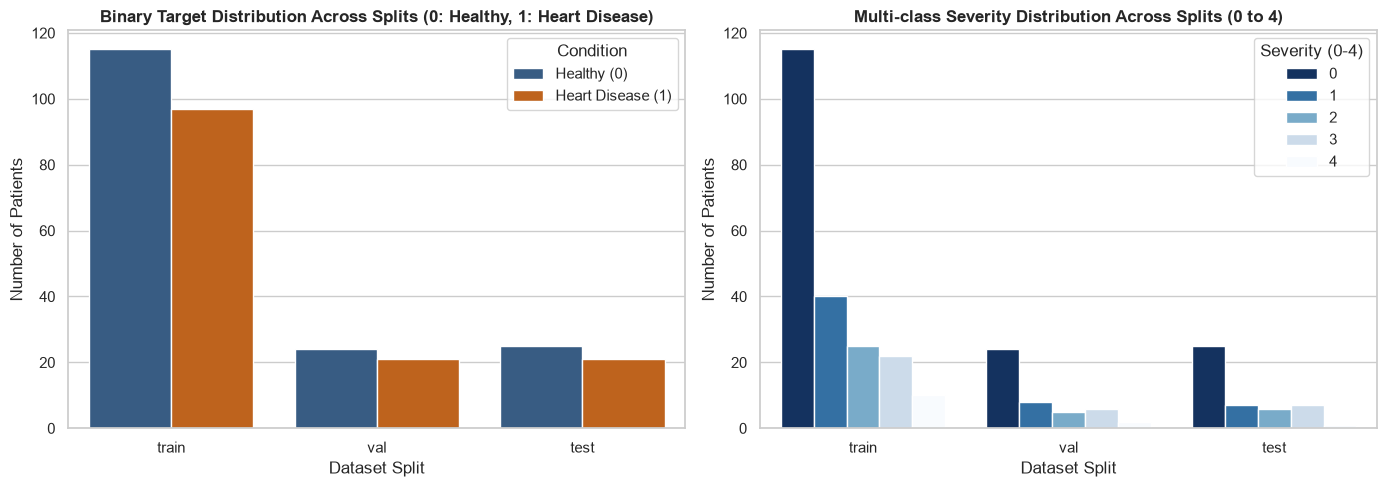

In [6]:
full_df = pd.read_csv('data/processed/full_preprocessed.csv')
os.makedirs('outputs', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary Target Plot
sns.countplot(
    data=full_df, 
    x='split', 
    hue='target_binary', 
    palette=['#2b5c8f', '#d95f02'], 
    ax=axes[0]
)
axes[0].set_title('Binary Target Distribution Across Splits (0: Healthy, 1: Heart Disease)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Dataset Split')
axes[0].set_ylabel('Number of Patients')
axes[0].legend(title='Condition', labels=['Healthy (0)', 'Heart Disease (1)'])

# Multi-class Target Plot
sns.countplot(
    data=full_df, 
    x='split', 
    hue='target', 
    palette='Blues_r', 
    ax=axes[1]
)
axes[1].set_title('Multi-class Severity Distribution Across Splits (0 to 4)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Dataset Split')
axes[1].set_ylabel('Number of Patients')
axes[1].legend(title='Severity (0-4)')

plt.tight_layout()
plt.savefig('outputs/splits_target_distribution.png', dpi=300)
plt.show()


## 6. ECG Diagnostic Image Manifest Splits

In [7]:
img_manifest = pd.read_csv('data/processed/image_manifest_splits.csv')
print("Total Diagnostic Images:", len(img_manifest))
print("\nImage Distribution per Category and Split:")
print(pd.crosstab(img_manifest['category'], img_manifest['split']))


Total Diagnostic Images: 30

Image Distribution per Category and Split:
split              test  train  val
category                           
ECG                   1      3    1
abnormal_heatbeat     1      3    1
his_MI                1      3    1
normal                1      3    1
uci - normal          1      3    1
uci - sick            1      3    1


## 7. Verification Checklist
- [x] Raw data loaded and preserved in `data/raw/`
- [x] 0 duplicates confirmed across all records and images
- [x] Missing values imputed using train mode (`ca`: 0.0, `thal`: 3.0)
- [x] Stratified splitting: 70% Train, 15% Val, 15% Test
- [x] Feature scaling fit strictly on train with no leakage
- [x] Artifacts saved to `data/processed/` and `models/scaler.pkl`
